# MSCS 634 - Advanced Big Data and Data Mining

## Lab 1: Data Visualization, Data Preprocessing and Statistical Analysis

Name: Kashif Ali Syed

In [1]:
import pandas as pd

ModuleNotFoundError: No module named 'pandas'

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd

print("Pandas is working")

Pandas is working


In [2]:
df = pd.read_csv("titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Matplotlib is building the font cache; this may take a moment.


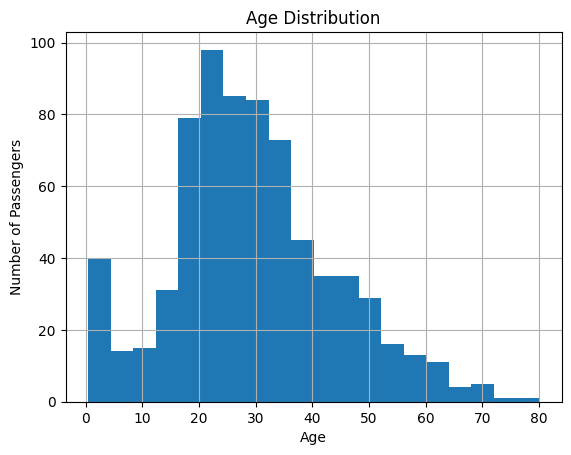

In [3]:
import matplotlib.pyplot as plt

df['Age'].hist(bins=20)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

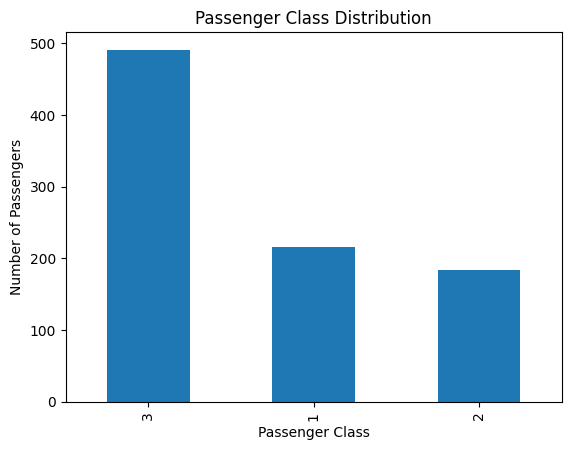

In [4]:
df['Pclass'].value_counts().plot(kind='bar')

plt.title('Passenger Class Distribution')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

plt.show()

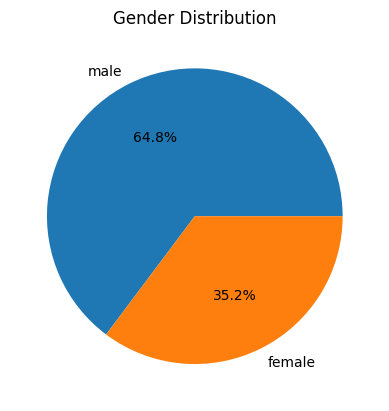

In [5]:
df['Sex'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Gender Distribution')

plt.show()

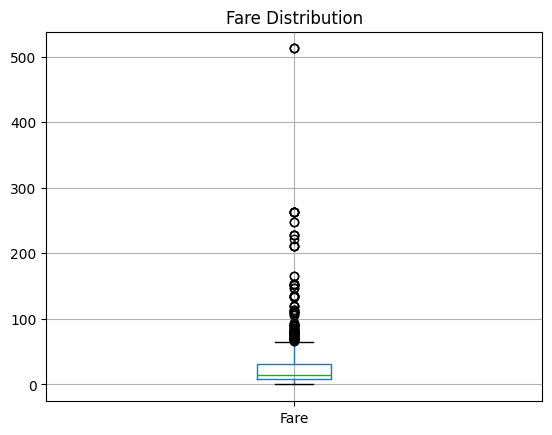

In [6]:
df.boxplot(column='Fare')

plt.title('Fare Distribution')

plt.show()

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)

Q1 = 7.9104
Q3 = 31.0
IQR = 23.0896


In [10]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower_bound) |
              (df['Fare'] > upper_bound)]

print("Number of outliers:", len(outliers))

outliers.head()

Number of outliers: 116


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.000000,3,2,19950,263.0000,C23 C25 C27,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,29.699118,1,0,PC 17569,146.5208,B78,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.000000,1,0,PC 17604,82.1708,NaN,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.000000,1,0,PC 17572,76.7292,D33,C


In [11]:
df_no_outliers = df[
    (df['Fare'] >= lower_bound) &
    (df['Fare'] <= upper_bound)
]

print("Original Rows:", len(df))
print("Rows After Removal:", len(df_no_outliers))

Original Rows: 891
Rows After Removal: 775


In [12]:
reduced_df = df.sample(frac=0.5, random_state=42)

print("Original Size:", len(df))
print("Reduced Size:", len(reduced_df))

Original Size: 891
Reduced Size: 446


In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['Age_Scaled'] = scaler.fit_transform(df[['Age']])

df[['Age','Age_Scaled']].head()

,Age,Age_Scaled
0,22.0,0.271174
1,38.0,0.472229
2,26.0,0.321438
3,35.0,0.434531
4,35.0,0.434531


In [14]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,18,40,100],
    labels=['Young','Adult','Senior']
)

df[['Age','Age_Group']].head()

,Age,Age_Group
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    str     
 4   Sex          891 non-null    str     
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    str     
 11  Embarked     889 non-null    str     
 12  Age_Scaled   891 non-null    float64 
 13  Age_Group    891 non-null    category
dtypes: category(1), float64(3), int64(5), str(5)
memory usage: 91.6 KB


In [16]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

print("Range:", df['Age'].max() - df['Age'].min())
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Variance:", df['Age'].var())
print("Standard Deviation:", df['Age'].std())

Range: 79.58
Q1: 22.0
Q3: 35.0
IQR: 13.0
Variance: 169.0523999372108
Standard Deviation: 13.002015226002882


In [17]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Age_Scaled
PassengerId,1.000000,-0.005007,-0.035144,0.033207,-0.057527,-0.001652,0.012658,0.033207
Survived,-0.005007,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307,-0.069809
Pclass,-0.035144,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500,-0.331339
Age,0.033207,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566,1.000000
SibSp,-0.057527,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651,-0.232625
Parch,-0.001652,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225,-0.179191
Fare,0.012658,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000,0.091566
Age_Scaled,0.033207,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566,1.000000
